In [2]:
# Install required libraries if needed (uncomment and run if libraries are missing)
# !pip install pandas numpy scikit-learn torch transformers datasets beautifulsoup4

# --- Standard Libraries ---
import pandas as pd
import numpy as np
import re
import os
import torch

# --- Data Handling and Cleaning ---
from bs4 import BeautifulSoup
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# --- Hugging Face Transformers & Datasets ---
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

# Define the folder path where your CSV files are located
DATA_FOLDER = os.getenv("VERITAS_DATA_PATH", "../Veritas-Engine-Data/dataset")

In [3]:
# --- 2.1 Load and Standardize DataFrames ---

# 1. Enron.csv (Assuming all are Legitimate, label=0)
enron_path = os.path.join(DATA_FOLDER, "Enron.csv")
enron_df = pd.read_csv(enron_path)
enron_df['text'] = enron_df['subject'].fillna('') + ' ' + enron_df['body'].fillna('')
enron_df = enron_df[['text', 'label']]
enron_df.columns = ['text', 'label']

# 2. spam.csv (ham=0, spam=1)
spam_path = os.path.join(DATA_FOLDER, "spam.csv")
spam_df = pd.read_csv(spam_path, encoding='latin-1')
spam_df = spam_df[['Category', 'Message']]
spam_df.columns = ['label_name', 'text']
spam_df['label'] = spam_df['label_name'].map({'ham': 0, 'spam': 1})
spam_df = spam_df[['text', 'label']]

# 3. Phishing_validation_emails (1).csv (Safe Email=0, Phishing Email=1)
phishing_path = os.path.join(DATA_FOLDER, "Phishing_validation_emails (1).csv")
phishing_val_df = pd.read_csv(phishing_path)
phishing_val_df.columns = ['text', 'label_name']
phishing_val_df['label'] = phishing_val_df['label_name'].map({'Safe Email': 0, 'Phishing Email': 1})
phishing_val_df = phishing_val_df[['text', 'label']]

# --- 2.2 Concatenate All DataFrames ---
master_df = pd.concat([enron_df, spam_df, phishing_val_df], ignore_index=True)

print(f"Total Combined Emails: {master_df.shape[0]}")
print("Initial Label Distribution (0=Legitimate, 1=Phishing):")
print(master_df['label'].value_counts())

Total Combined Emails: 37339
Initial Label Distribution (0=Legitimate, 1=Phishing):
label
0    21616
1    15723
Name: count, dtype: int64


In [4]:
# --- Deep Text Cleaning Function ---
def clean_email_text(text):
    text = str(text).lower()
    
    # 1. Remove HTML tags using BeautifulSoup (more reliable than regex)
    try:
        soup = BeautifulSoup(text, 'html.parser')
        text = soup.get_text()
    except:
        # Fallback to a simple regex if BeautifulSoup fails
        text = re.sub(r'<.*?>', ' ', text)

    # 2. Replace URLs with a placeholder [URL]
    text = re.sub(r'http\S+|www\S+|https\S+', '[URL]', text)
    
    # 3. Replace email addresses/metadata with placeholders
    text = re.sub(r'\S*@\S*\s?', '[EMAIL_ADDRESS]', text)
    text = re.sub(r'from : .* to : .* subject : ', ' ', text)
    text = re.sub(r'forwarded by .* on .*', ' ', text)
    text = re.sub(r'\( see attached file : \S* \. xls \)', '[ATTACHMENT]', text)
    text = re.sub(r'\S* \. xls', '[ATTACHMENT]', text)
    
    # 4. Remove long dashes/forwarding lines
    text = re.sub(r'-{3,}', ' ', text)
    
    # 5. Remove remaining punctuation and numbers, keeping only letters and spaces
    # We keep the placeholders [] explicitly.
    text = re.sub(r'[^a-zA-Z\s\[\]]', ' ', text)
    
    # 6. Remove extra whitespace/newlines
    text = re.sub('\s+', ' ', text).strip()
    
    return text

# Apply the cleaning function and save the final prepared DataFrame
master_df['text'] = master_df['text'].apply(clean_email_text)
final_df = master_df[['text', 'label']].copy()

print("\nCleaning Applied. Sample Cleaned Text:")
print(final_df['text'].head())

<>:31: SyntaxWarning: invalid escape sequence '\s'
<>:31: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_22724\2559105469.py:31: SyntaxWarning: invalid escape sequence '\s'
  text = re.sub('\s+', ' ', text).strip()



Cleaning Applied. Sample Cleaned Text:
0    hpl nom for may see attached file hplno [ATTAC...
1    re nom actual vols for th enron capital trade ...
2    enron actuals for march april estimated actual...
3    hpl nom for may see attached file hplno [ATTAC...
4    hpl nom for june see attached file hplno [ATTA...
Name: text, dtype: object


In [5]:
# --- Data Split (80/10/10) ---

# Use the final_df created in the previous step (containing 'text' and 'label')
# Ensure final_df is loaded/defined from the previous steps
# If running in a new session, uncomment and run:
# final_df = pd.read_csv('veritas_cleaned_data.csv') 

# 1. Split 80% for Training, 20% for Temp (Validation + Test)
train_df, temp_df = train_test_split(final_df, test_size=0.2, random_state=42, stratify=final_df['label'])

# 2. Split Temp 50/50 for Validation (10%) and Test (10%)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print("\n--- Data Split Sizes ---")
print(f"Training Set: {len(train_df)} rows")
print(f"Validation Set: {len(val_df)} rows")
print(f"Test Set: {len(test_df)} rows")


--- Data Split Sizes ---
Training Set: 29871 rows
Validation Set: 3734 rows
Test Set: 3734 rows


In [6]:
# --- DistilBERT Tokenization ---
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 512 

# 1. Initialize DistilBERT's tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

# 2. Convert Pandas DataFrames to Hugging Face Dataset objects
# Rename 'label' column to 'labels' as required by the Trainer
train_dataset = Dataset.from_pandas(train_df, preserve_index=False).rename_column("label", "labels")
val_dataset = Dataset.from_pandas(val_df, preserve_index=False).rename_column("label", "labels")
test_dataset = Dataset.from_pandas(test_df, preserve_index=False).rename_column("label", "labels")

# 3. Define the tokenization function
def tokenize_function(examples):
    # This prepares the data for the model: padding/truncation to MAX_LEN
    return tokenizer(examples['text'], 
                     padding="max_length", 
                     truncation=True, 
                     max_length=MAX_LEN)

# 4. Apply the tokenizer and remove the original 'text' column
tokenized_train = train_dataset.map(tokenize_function, batched=True).remove_columns(["text"])
tokenized_val = val_dataset.map(tokenize_function, batched=True).remove_columns(["text"])
tokenized_test = test_dataset.map(tokenize_function, batched=True).remove_columns(["text"])

print("\n--- Tokenization Complete. Data is now numerical. ---")
print("Example tokenized data point structure (IDs, Mask, Label):", tokenized_train[0].keys())

Map:   0%|          | 0/29871 [00:00<?, ? examples/s]

Map:   0%|          | 0/3734 [00:00<?, ? examples/s]

Map:   0%|          | 0/3734 [00:00<?, ? examples/s]


--- Tokenization Complete. Data is now numerical. ---
Example tokenized data point structure (IDs, Mask, Label): dict_keys(['labels', 'input_ids', 'attention_mask'])


In [8]:
# Re-importing necessary libraries for a clean block execution
import numpy as np
import torch
from transformers import DistilBertForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Configuration
MODEL_NAME = "distilbert-base-uncased"

# 1. Load the pre-trained model
# The warning about uninitialized weights is expected and means the model is ready to be trained!
model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# 2. Define the metrics function
def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    
    # Calculate key metrics: Precision, Recall, F1 for the Phishing class (1)
    precision, recall, f1, _ = precision_recall_fscore_support(p.label_ids, preds, average='binary')
    acc = accuracy_score(p.label_ids, preds)
    
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# 3. Define Training Arguments (FIX APPLIED: using 'eval_strategy')
training_args = TrainingArguments(
    output_dir='./veritas_results',        
    num_train_epochs=3,                   
    per_device_train_batch_size=16,       
    per_device_eval_batch_size=64,        
    warmup_steps=500,                     
    weight_decay=0.01,                    
    logging_steps=500,
    eval_strategy="epoch",          # <-- CORRECTED: Changed from 'evaluation_strategy' to 'eval_strategy'
    save_strategy="epoch",                
    load_best_model_at_end=True,          
    metric_for_best_model='f1',           
)

# 4. Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train, # Ensure tokenized_train is available from Step 4.2
    eval_dataset=tokenized_val,    # Ensure tokenized_val is available from Step 4.2
    tokenizer=tokenizer,           # Ensure tokenizer is available
    compute_metrics=compute_metrics,
)
f
# 5. Train the model
print("\n*** Starting DistilBERT Fine-Tuning... ***")
# Note: This is the longest step. It's time to let the training run!
trainer.train()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\ASUS\AppData\Local\Temp\ipykernel_22724\1520729435.py:45: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(



*** Starting DistilBERT Fine-Tuning... ***


C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.069000,0.041277,0.987145,0.984791,0.981680,0.987921
2,0.020700,0.052258,0.988216,0.985978,0.988498,0.983471
3,0.004800,0.050349,0.991430,0.989822,0.990452,0.989193


C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=5601, training_loss=0.0476271474154969, metrics={'train_runtime': 71476.7337, 'train_samples_per_second': 1.254, 'train_steps_per_second': 0.078, 'total_flos': 1.1870800995760128e+16, 'train_loss': 0.0476271474154969, 'epoch': 3.0})

In [9]:
from transformers import DistilBertTokenizerFast

# --- 1. Final Evaluation on the UNSEEN Test Set ---
print("\n*** Final Evaluation on UNSEEN Test Set (Your Project's Final Accuracy) ***")
# The Trainer automatically loads the best model checkpoint based on the validation F1 score.
test_results = trainer.evaluate(tokenized_test) 
print(test_results)

# --- 2. Save the Final Model for Deployment ---
MODEL_OUTPUT_DIR = './veritas_engine_model'

# Save the best model (trainer.model) and its tokenizer
trainer.model.save_pretrained(MODEL_OUTPUT_DIR)
tokenizer.save_pretrained(MODEL_OUTPUT_DIR)

print(f"\nFinal Best Model and Tokenizer saved to: {MODEL_OUTPUT_DIR}")


*** Final Evaluation on UNSEEN Test Set (Your Project's Final Accuracy) ***


C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.061978839337825775, 'eval_accuracy': 0.9895554365291912, 'eval_f1': 0.9875677398788651, 'eval_precision': 0.9897763578274761, 'eval_recall': 0.9853689567430025, 'eval_runtime': 693.848, 'eval_samples_per_second': 5.382, 'eval_steps_per_second': 0.085, 'epoch': 3.0}

Final Best Model and Tokenizer saved to: ./veritas_engine_model


In [11]:
import torch
import numpy as np
import re
from bs4 import BeautifulSoup
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
import os

# --- Configuration (Must match the saved model path and parameters) ---
MODEL_PATH = './veritas_engine_model'
MAX_LEN = 512 

# 1. Load the model and tokenizer
# Use the best model saved from your successful training run
try:
    # Check for GPU (use CPU if not found)
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {DEVICE}")

    tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_PATH)
    model = DistilBertForSequenceClassification.from_pretrained(MODEL_PATH)
    model.to(DEVICE)
    model.eval() # Set model to evaluation mode
    print("Model loaded successfully for inference.")
except Exception as e:
    print(f"Error loading model: {e}")
    print("Please ensure the directory './veritas_engine_model' exists and contains model files.")
    
# --- 2. Inference Function (Replicates Preprocessing) ---

def predict_email_class(text):
    # --- A. CLEANING (MUST be identical to the training cleaning function) ---
    def clean_text_for_inference(text):
        text = str(text).lower()
        try:
            soup = BeautifulSoup(text, 'html.parser')
            text = soup.get_text()
        except:
            text = re.sub(r'<.*?>', ' ', text)
        
        # Replace URLs, emails, and remove metadata/dashes
        text = re.sub(r'http\S+|www\S+|https\S+', '[URL]', text)
        text = re.sub(r'\S*@\S*\s?', '[EMAIL_ADDRESS]', text)
        text = re.sub(r'from : .* to : .* subject : ', ' ', text)
        text = re.sub(r'forwarded by .* on .*', ' ', text)
        text = re.sub(r'\( see attached file : \S* \. xls \)', '[ATTACHMENT]', text)
        text = re.sub(r'\S* \. xls', '[ATTACHMENT]', text)
        text = re.sub(r'-{3,}', ' ', text)
        text = re.sub(r'[^a-zA-Z\s\[\]]', ' ', text)
        text = re.sub('\s+', ' ', text).strip()
        return text

    cleaned_text = clean_text_for_inference(text)
    
    # --- B. TOKENIZATION ---
    encoding = tokenizer.encode_plus(
        cleaned_text,
        max_length=MAX_LEN,
        truncation=True,
        padding='max_length',
        return_tensors='pt' # Return PyTorch tensors
    )
    
    # --- C. PREDICTION ---
    input_ids = encoding['input_ids'].to(DEVICE)
    attention_mask = encoding['attention_mask'].to(DEVICE)
    
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        
    logits = outputs.logits
    # Convert to probabilities using Softmax
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    
    # Label 1: Phishing, Label 0: Legitimate
    prediction_index = np.argmax(probs)
    result_label = "PHISHING" if prediction_index == 1 else "LEGITIMATE"
    confidence = probs[prediction_index] * 100 
    
    return result_label, confidence, cleaned_text

# Helper function to print results neatly
def run_test(name, email_text):
    label, confidence, cleaned_text = predict_email_class(email_text)
    print("=" * 60)
    print(f"Test Case: {name}")
    print(f"Model Prediction: **{label}**")
    print(f"Confidence: **{confidence:.2f}%**")
    print(f"\nCleaned Text (Input to BERT): {cleaned_text[:150]}...")
    print("=" * 60)

<>:49: SyntaxWarning: invalid escape sequence '\s'
<>:49: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_22724\4236881701.py:49: SyntaxWarning: invalid escape sequence '\s'
  text = re.sub('\s+', ' ', text).strip()


Using device: cpu
Model loaded successfully for inference.


In [20]:
test_case_6 = """
Subject: Package Delivery Attempted: Respond Now
Hello Customer:
We tried to deliver your package, but no-one was available to sign. Your package is held at a warehouse. 

To reschedule your delivery, please fill out the short form at this website address: 
http://tracking-logistics-update.net/form-reschedule-38741

We require your full current address to verify delivery. Reply fast or the package will be returned to sender. 
Thank you for your patients! 
Tracking ID: USA987654321
"""
run_test("6. Shipping Notification (Sloppy Ambiguity)", test_case_6)

Test Case: 6. Shipping Notification (Sloppy Ambiguity)
Model Prediction: **PHISHING**
Confidence: **100.00%**

Cleaned Text (Input to BERT): subject package delivery attempted respond now hello customer we tried to deliver your package but no one was available to sign your package is held a...


In [21]:
# Re-import necessary libraries
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support
import numpy as np
import pandas as pd

# 1. Run Prediction on the UNSEEN Test Set
# This generates the raw predictions (logits) and extracts the true labels.
predictions = trainer.predict(tokenized_test)
true_labels = predictions.label_ids
predicted_logits = predictions.predictions

# Convert logits to final class predictions (0 or 1)
predicted_labels = np.argmax(predicted_logits, axis=1)

# 2. Calculate the Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)

# 3. Calculate Core Metrics
# Calculate metrics for the 'Phishing' class (1)
precision, recall, f1, _ = precision_recall_fscore_support(
    true_labels, predicted_labels, average='binary', pos_label=1
)
# Overall Accuracy
accuracy = accuracy_score(true_labels, predicted_labels)

# Store results in a dictionary for easy reporting
report_metrics = {
    'Accuracy': accuracy,
    'F1-Score (Phishing)': f1,
    'Precision (Phishing)': precision,
    'Recall (Phishing)': recall
}

print("\n--- Final Quantitative Report ---")
print("Confusion Matrix (Actual vs. Predicted):")
print(cm)
print("\nKey Performance Metrics:")
print(pd.Series(report_metrics))

C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



--- Final Quantitative Report ---
Confusion Matrix (Actual vs. Predicted):
[[2146   16]
 [  23 1549]]

Key Performance Metrics:
Accuracy                0.989555
F1-Score (Phishing)     0.987568
Precision (Phishing)    0.989776
Recall (Phishing)       0.985369
dtype: float64


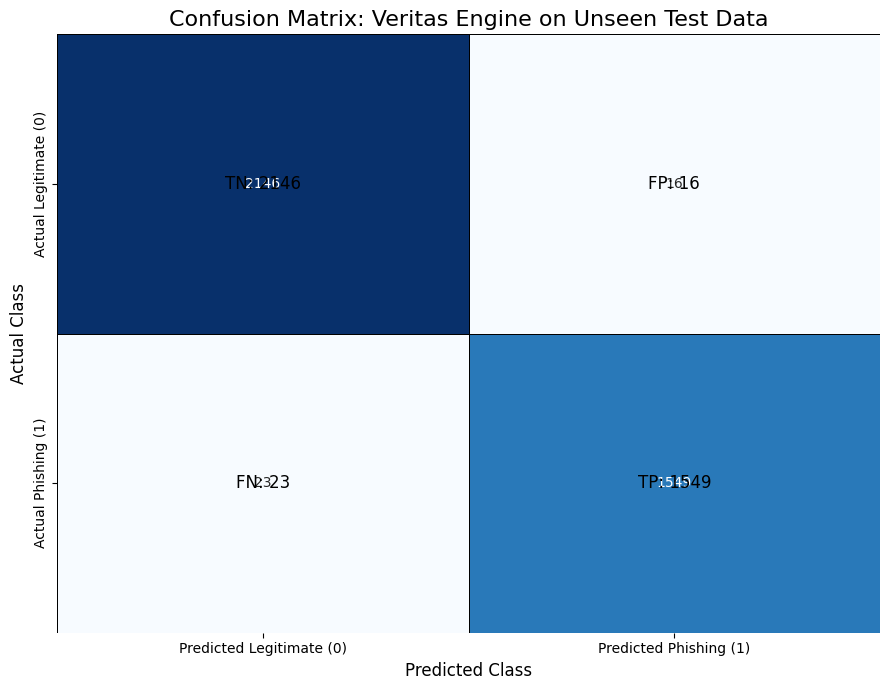

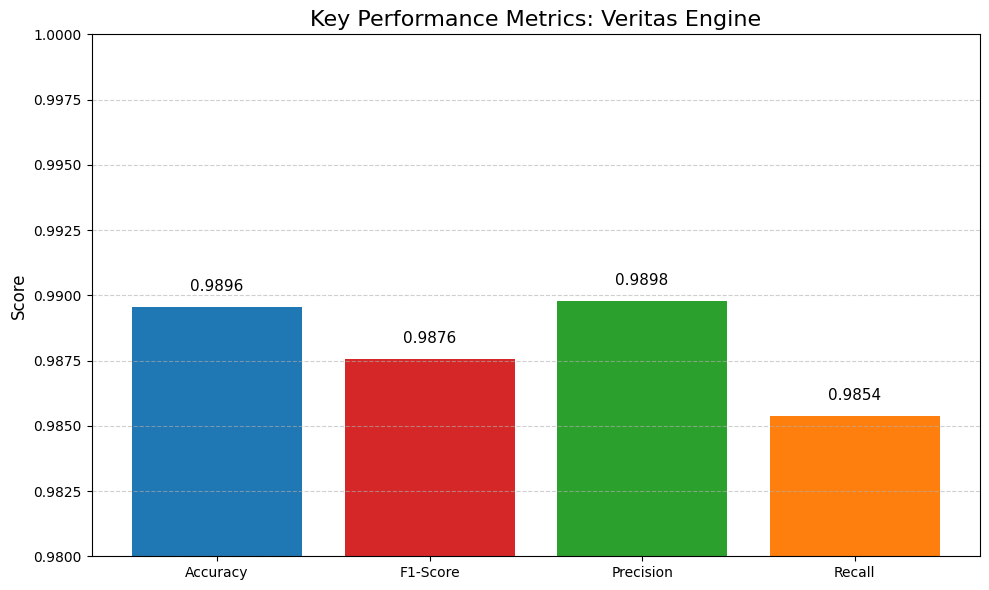

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Data from Final Evaluation ---
# Confusion Matrix Data: [[TN, FP], [FN, TP]]
cm_data = np.array([[2146, 16],
                    [23, 1549]])
cm_labels = ['Actual Legitimate (0)', 'Actual Phishing (1)']
pred_labels = ['Predicted Legitimate (0)', 'Predicted Phishing (1)']

# Key Performance Metrics
metrics_data = {
    'Metric': ['Accuracy', 'F1-Score', 'Precision', 'Recall'],
    'Score': [0.989555, 0.987568, 0.989776, 0.985369]
}
metrics_df = pd.DataFrame(metrics_data)

# --- Plot 1: Confusion Matrix Heatmap ---
cm_df = pd.DataFrame(cm_data, index=cm_labels, columns=pred_labels)

plt.figure(figsize=(9, 7))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', 
            linewidths=0.5, linecolor='black', cbar=False)

# Add custom labels for True/False Positives/Negatives inside the cells
plt.text(0.5, 0.5, f"TN: {cm_data[0, 0]}", ha='center', va='center', color='black', fontsize=12)
plt.text(1.5, 0.5, f"FP: {cm_data[0, 1]}", ha='center', va='center', color='black', fontsize=12)
plt.text(0.5, 1.5, f"FN: {cm_data[1, 0]}", ha='center', va='center', color='black', fontsize=12)
plt.text(1.5, 1.5, f"TP: {cm_data[1, 1]}", ha='center', va='center', color='black', fontsize=12)

plt.title('Confusion Matrix: Veritas Engine on Unseen Test Data', fontsize=16)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('Actual Class', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_heatmap.png')
plt.show()

# --- Plot 2: Key Performance Metrics Bar Chart ---
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_df['Metric'], metrics_df['Score'], 
               color=['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e'])

# Add text labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.0005, f'{yval:.4f}', ha='center', va='bottom', fontsize=11)

plt.ylim(0.98, 1.0) # Zoomed in to show differences clearly
plt.title('Key Performance Metrics: Veritas Engine', fontsize=16)
plt.ylabel('Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('performance_metrics_bar.png')
plt.show()